In [ ]:
# %%

# 0. load libraries
import os
os.chdir("/hpc/home/yx306/RDR")
os.getcwd()


import numpy as np
import matplotlib.pyplot as plt
import utils.help_func as help
import torch
import utils.DRE_func as dre
from matplotlib.colors import TwoSlopeNorm
from importlib import reload


# for reproducibility
SEED = 123

import random
random.seed(SEED)          # Python built-in
np.random.seed(SEED)       # NumPy
torch.manual_seed(SEED)    # PyTorch (CPU)
torch.cuda.manual_seed_all(SEED)  # PyTorch (all GPU devices)


# (optional but recommended for strict reproducibility)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

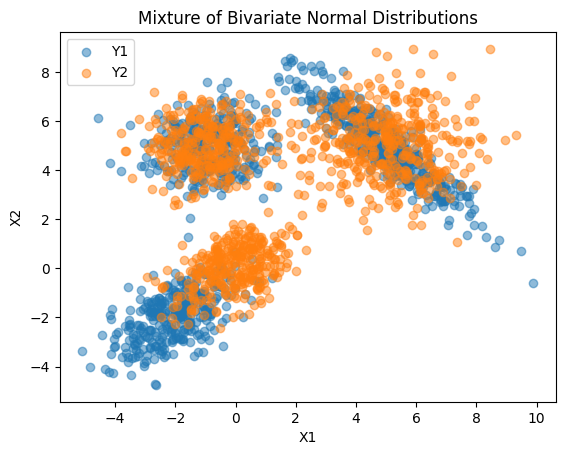

In [ ]:
# %%

# =====================================
# ======== 2D comparison ==============
# =====================================

n1_samples = 1000
n2_samples = 1000
weights = [0.3, 0.3,0.4]

# Means of the bivariate normal distributions
# means1 = [np.array([0, 0]), np.array([-1, 5]),  np.array([5, 5])]
# means2 = [np.array([-2, -2]), np.array([-1, 5]),  np.array([5, 5])]
means2 = [np.array([0, 0]), np.array([-1, 5]),  np.array([5, 5])]
means1 = [np.array([-2, -2]), np.array([-1, 5]),  np.array([5, 5])]

# Covariance matrices of the bivariate normal distributions
# covariances1 = [np.array([[1, 0.5], [0.5, 1]]), 
#                np.array([[1, 0], [0, 1]]), 
#                2*np.array([[1, 0], [0, 1]])]
# covariances2 = [np.array([[1, 0.5], [0.5, 1]]), 
#                np.array([[1, 0], [0, 1]]), 
#                2*np.array([[1, -0.9], [-0.9, 1]])]
covariances2 = [np.array([[1, 0.5], [0.5, 1]]), 
               np.array([[1, 0], [0, 1]]), 
               2*np.array([[1, 0], [0, 1]])]
covariances1 = [np.array([[1, 0.5], [0.5, 1]]), 
               np.array([[1, 0], [0, 1]]), 
               2*np.array([[1, -0.9], [-0.9, 1]])]


Y1 = help.sample_mixture_normal_2d(n1_samples, weights, means1, covariances1)
Y2 = help.sample_mixture_normal_2d(n2_samples, weights, means2, covariances2)

n_val = 500
Y1_val = help.sample_mixture_normal_2d(n_val, weights, means1, covariances1)
Y2_val = help.sample_mixture_normal_2d(n_val, weights, means2, covariances2)


# Plot the generated samples
plt.scatter(Y1[:, 0], Y1[:, 1], alpha=0.5, label = 'Y1')
plt.scatter(Y2[:, 0], Y2[:, 1], alpha=0.5, label = 'Y2')
plt.title('Mixture of Bivariate Normal Distributions')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

/hpc/home/yx306/.local/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch    0: loss=-0.000014 | val_loss=-0.000065
Epoch  100: loss=-0.004018 | val_loss=-0.004501
Epoch  200: loss=-0.018849 | val_loss=-0.021266
Epoch  300: loss=-0.037570 | val_loss=-0.049381
Epoch  400: loss=-0.041761 | val_loss=-0.055502
Epoch  500: loss=-0.045262 | val_loss=-0.059793
Epoch  600: loss=-0.050523 | val_loss=-0.065454
Epoch  700: loss=-0.058339 | val_loss=-0.073535
Epoch  800: loss=-0.065574 | val_loss=-0.080475
Epoch  900: loss=-0.070338 | val_loss=-0.084562
Best epoch = 999 | val_loss = -0.087218


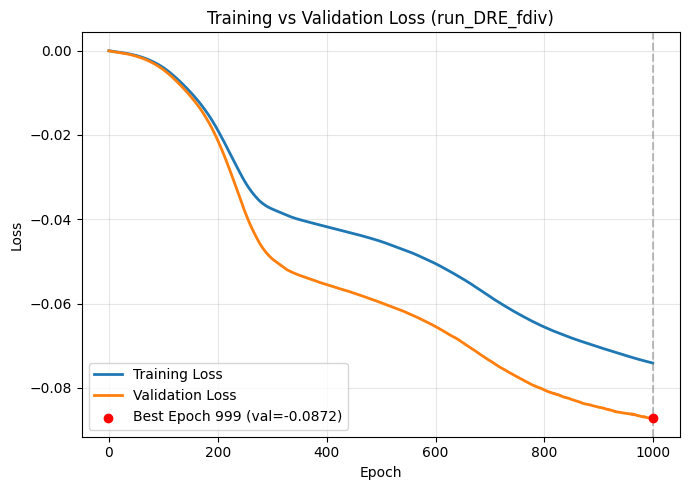

In [ ]:
# %%

# 2. (default) estimate the density ratio using f-div loss function and MLP
reload(dre)

num_epochs = 1000

x_p = torch.from_numpy(np.array(Y1, dtype = np.float32))
x_q = torch.from_numpy(np.array(Y2, dtype = np.float32))

x_p_val = torch.from_numpy(np.array(Y1_val, dtype = np.float32))
x_q_val = torch.from_numpy(np.array(Y2_val, dtype = np.float32))

stacked_Y = np.vstack((Y1, Y2))
stacked_Y_val = np.vstack((Y1_val, Y2_val))
x_mixed = torch.from_numpy(np.array(stacked_Y, dtype = np.float32))
x_mixed_val = torch.from_numpy(np.array(stacked_Y_val, dtype = np.float32))

model1, losses1, val_loss = dre.run_DRE_fdiv(x_p,x_mixed,xi=0.5,
                                    x_p_val=x_p_val, x_q_val=x_mixed_val,
                                   num_epochs = num_epochs,
                                   early_patience = 5,
                                   loss_method='Hellinger')

plt.figure(figsize=(7,5))

# Plot training loss (every epoch)
plt.plot(np.arange(len(losses1)), losses1, label="Training Loss", color="tab:blue", linewidth=2)

# Plot validation loss (may have fewer points)
if val_loss and len(val_loss) > 0:
    plt.plot(np.arange(len(val_loss)), val_loss, label="Validation Loss", color="tab:orange", linewidth=2)
    # mark best epoch
    best_epoch = int(np.argmin(val_loss))
    best_val = float(val_loss[best_epoch])
    plt.axvline(best_epoch, color="gray", linestyle="--", alpha=0.5)
    plt.scatter(best_epoch, best_val, color="red", zorder=5, label=f"Best Epoch {best_epoch} (val={best_val:.4f})")
    print(f"Best epoch = {best_epoch} | val_loss = {best_val:.6f}")
else:
    print("No validation losses recorded.")

# Styling
plt.title("Training vs Validation Loss (run_DRE_fdiv)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Visualize the Learned Function w(x)


max_ranges = [10,8]
min_ranges = [-4,-4]


# stacked_Y_tensor = torch.from_numpy(stacked_Y).float()

p1 = help.twoD_mixture_density(stacked_Y, weights, means1, covariances1)
p2 = help.twoD_mixture_density(stacked_Y, weights, means2, covariances2)

ratios = 2*p1/(p1+p2)



with torch.no_grad():
    w_vis1 = model1(torch.from_numpy(stacked_Y).float())

w_vis_np1 = w_vis1.detach().numpy()


# evaluated on observed points

stacked_Y_train = np.vstack((Y1, Y2))
p1 = help.twoD_mixture_density(stacked_Y, weights, means1, covariances1)
p2 = help.twoD_mixture_density(stacked_Y, weights, means2, covariances2)

ratios_train = 2*p1/(p1+p2)



with torch.no_grad():
    w_vis1_train = model1(torch.from_numpy(stacked_Y_train).float())

w_vis1_train = w_vis1_train.detach().numpy()

In [ ]:
# %% 

# uLSIF
from densratio import densratio

# Fit uLSIF (the default)
result_uLSIF = densratio(Y1, stacked_Y, alpha=0, sigma_range=[0.1, 0.3, 1.0]) 
# r(x) estimates the density ratio p(x)/q(x)
r_uLSIF = result_uLSIF.compute_density_ratio(stacked_Y)

RuLSIF starting...
Searching for the optimal sigma and lambda...
sigma = 0.10000, lambda = 0.00100, score = 0.19863
sigma = 0.10000, lambda = 0.01000, score = -0.01023
sigma = 0.10000, lambda = 0.10000, score = -0.00308
sigma = 0.10000, lambda = 1.00000, score = -0.00078
sigma = 0.10000, lambda = 10.00000, score = -0.00010
sigma = 0.10000, lambda = 100.00000, score = -0.00001
sigma = 0.10000, lambda = 1000.00000, score = -0.00000
sigma = 0.10000, lambda = 10000.00000, score = -0.00000
sigma = 0.10000, lambda = 100000.00000, score = -0.00000
sigma = 0.10000, lambda = 1000000.00000, score = -0.00000
sigma = 0.10000, lambda = 10000000.00000, score = -0.00000
sigma = 0.10000, lambda = 100000000.00000, score = -0.00000
sigma = 0.10000, lambda = 1000000000.00000, score = -0.00000
sigma = 0.30000, lambda = 0.00100, score = 1.69728
sigma = 0.30000, lambda = 0.01000, score = -0.20312
sigma = 0.30000, lambda = 0.10000, score = -0.12900
sigma = 0.30000, lambda = 1.00000, score = -0.03190
sigma = 

In [ ]:
# %%

# KLIEP
import numpy as np
from adapt.instance_based import KLIEP

kliep = KLIEP(kernel="rbf", max_centers=100, cv=5, verbose=0)
kliep.fit(stacked_Y,np.zeros(len(stacked_Y)), Xt=Y1)              # fits the ratio estimator
r_KLIEP = kliep.predict_weights(stacked_Y)  # evaluate p/q on test data

2025-12-22 21:25:16.049488: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766456716.068076 1219367 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766456716.073779 1219367 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766456716.088959 1219367 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766456716.088981 1219367 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766456716.088984 1219367 computation_placer.cc:177] computation placer alr

In [ ]:
# %%

# Binary classification rule
# Xp ~ p, Xq ~ q
reload(help)
r_hat, eta, info = help.density_ratio_classifier(Y1, Y2, 
                            X_eval=stacked_Y, balance_priors=True)

# If you use RDR later:
r_bin = 2 * r_hat / (1 + r_hat)

Text(0, 0.5, 'x2')

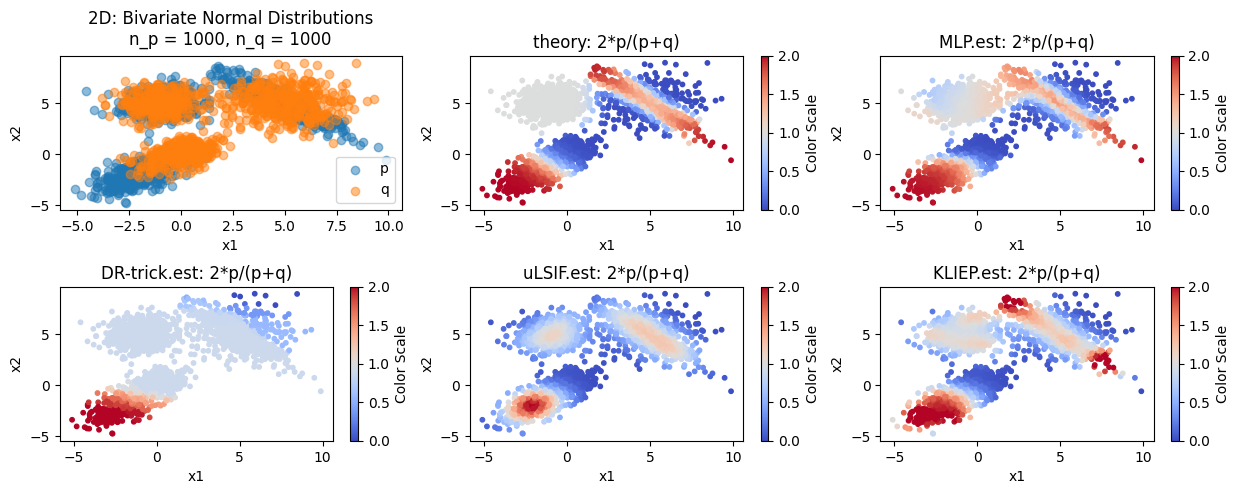

In [ ]:
# %% visualize

# Create two subplots side by side
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 5))
fig.subplots_adjust(hspace=0.50) 
color_range = [0,2]

# raw data
ax  = axs[0,0]
ax.scatter(Y1[:, 0], Y1[:, 1], alpha=0.5, label = 'p')
ax.scatter(Y2[:, 0], Y2[:, 1], alpha=0.5, label = 'q')
ax.set_title(
    f'2D: Bivariate Normal Distributions\nn_p = {n1_samples}, n_q = {n2_samples}',
    linespacing=1.2,  # spacing between the two lines
    pad=8             # distance from axes to title
)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend()

# Theory r
ax  = axs[0,1]
sc=ax.scatter(stacked_Y_train[:,0], stacked_Y_train[:,1], c=ratios_train, 
                     cmap="coolwarm", marker='o', s=10,
                     norm = TwoSlopeNorm(vmin=color_range[0], 
                                         vcenter=1, 
                                         vmax=color_range[1]) ) # s is the marker size
ax.set_title('theory: 2*p/(p+q)')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Color Scale')
ax.set_xlabel('x1')
ax.set_ylabel('x2')

# MLP r
ax  = axs[0,2]
sc=ax.scatter(stacked_Y_train[:,0], stacked_Y_train[:,1], c=w_vis1_train, 
                     cmap="coolwarm", marker='o', s=10,
                     norm = TwoSlopeNorm(vmin=color_range[0], 
                                         vcenter=1, 
                                         vmax=color_range[1]) ) # s is the marker size
ax.set_title('MLP.est: 2*p/(p+q)')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Color Scale')
ax.set_xlabel('x1')
ax.set_ylabel('x2')

# bin r
ax  = axs[1,0]
sc=ax.scatter(stacked_Y_train[:,0], stacked_Y_train[:,1], c=r_bin, 
                     cmap="coolwarm", marker='o', s=10,
                     norm = TwoSlopeNorm(vmin=color_range[0], 
                                         vcenter=1, 
                                         vmax=color_range[1]) ) # s is the marker size
ax.set_title('DR-trick.est: 2*p/(p+q)')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Color Scale')
ax.set_xlabel('x1')
ax.set_ylabel('x2')

# uLSIF r
ax  = axs[1,1]
sc=ax.scatter(stacked_Y_train[:,0], stacked_Y_train[:,1], c=r_uLSIF, 
                     cmap="coolwarm", marker='o', s=10,
                     norm = TwoSlopeNorm(vmin=color_range[0], 
                                         vcenter=1, 
                                         vmax=color_range[1]) ) # s is the marker size
ax.set_title('uLSIF.est: 2*p/(p+q)')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Color Scale')
ax.set_xlabel('x1')
ax.set_ylabel('x2')

# KLIEP r
ax  = axs[1,2]
sc=ax.scatter(stacked_Y_train[:,0], stacked_Y_train[:,1], c=r_KLIEP, 
                     cmap="coolwarm", marker='o', s=10,
                     norm = TwoSlopeNorm(vmin=color_range[0], 
                                         vcenter=1, 
                                         vmax=color_range[1]) ) # s is the marker size
ax.set_title('KLIEP.est: 2*p/(p+q)')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Color Scale')
ax.set_xlabel('x1')
ax.set_ylabel('x2')

In [ ]:
# %%

# compare MSE
# true ratios (e.g., r_true = p(x)/q(x) or 2p/(p+q))
r_true = ratios_train

# estimated ratios
r_mlp   = w_vis1_train   # from your neural network
r_ulsif = r_uLSIF        # from densratio/uLSIF
r_kliep = r_KLIEP        # from ADAPT.KLIEP (make sure orientation is p/q)

# ensure consistent shapes and finite values
def mse(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.mean((y_true[mask] - y_pred[mask])**2)

mse_mlp   = mse(r_true, r_mlp)
mse_ulsif = mse(r_true, r_ulsif)
mse_kliep = mse(r_true, r_kliep)
mse_bin = mse(r_true, r_bin)


print(f"MSE (MLP):   {mse_mlp:.4f}")
print(f"MSE (DR-trick):   {mse_bin:.4f}")
print(f"MSE (uLSIF): {mse_ulsif:.4f}")
print(f"MSE (KLIEP): {mse_kliep:.4f}")

MSE (MLP):   0.0311
MSE (DR-trick):   0.2149
MSE (uLSIF): 0.1769
MSE (KLIEP): 0.0477


K^T K ≈
 [[1.00000000e+00 3.56588244e-17]
 [3.56588244e-17 1.00000000e+00]]
(1000, 40) (1000, 40)
Avg back-projection error: Y1 0.254, Y2 0.249


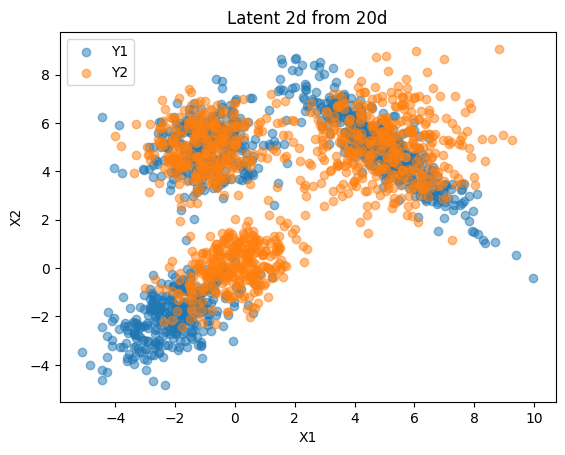

In [ ]:
# %%

# =====================================
# ======== 20D comparison ==============
# =====================================
# --- 1) make a random orthonormal embedding K: R^{20x2}, K^T K = I_2
reload(help)


D = 40
K = help.make_orthonormal_K(D=D, d=2, seed=42)   # fixed embedding for both groups
print("K^T K ≈\n", K.T @ K)                  # sanity: should be ~ identity

# choose noise to control SNR; try 0.2–0.5 first
noise_sd = 0.2

Y1_20 = help.lift_to_20D(Y1, K, noise_sd=noise_sd, seed=123)
Y2_20 = help.lift_to_20D(Y2, K, noise_sd=noise_sd, seed=456)

Y1_20_val = help.lift_to_20D(Y1_val, K, noise_sd=noise_sd, seed=123)
Y2_20_val = help.lift_to_20D(Y2_val, K, noise_sd=noise_sd, seed=456)

print(Y1_20.shape, Y2_20.shape)  # (1000, 20) (1000, 20)

# --- Optional sanity check: project back to 2D (least-squares since columns are orthonormal)
Y1_back = Y1_20 @ K            # ≈ Y1 (blurred by noise)
Y2_back = Y2_20 @ K
err1 = np.mean(np.linalg.norm(Y1_back - Y1, axis=1))
err2 = np.mean(np.linalg.norm(Y2_back - Y2, axis=1))
print(f"Avg back-projection error: Y1 {err1:.3f}, Y2 {err2:.3f}")

# Plot the generated samples
plt.scatter(Y1_back[:, 0], Y1_back[:, 1], alpha=0.5, label = 'Y1')
plt.scatter(Y2_back[:, 0], Y2_back[:, 1], alpha=0.5, label = 'Y2')
plt.title('Latent 2d from 20d')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

/hpc/home/yx306/.local/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch    0: loss=-0.000021 | val_loss=-0.000036
Epoch  100: loss=-0.004832 | val_loss=-0.005560
Epoch  200: loss=-0.017983 | val_loss=-0.019388
Epoch  300: loss=-0.043930 | val_loss=-0.045278
[EarlyStop] epoch 379 | best_val=-0.051204 (patience 5)
Best epoch = 378 | val_loss = -0.051212


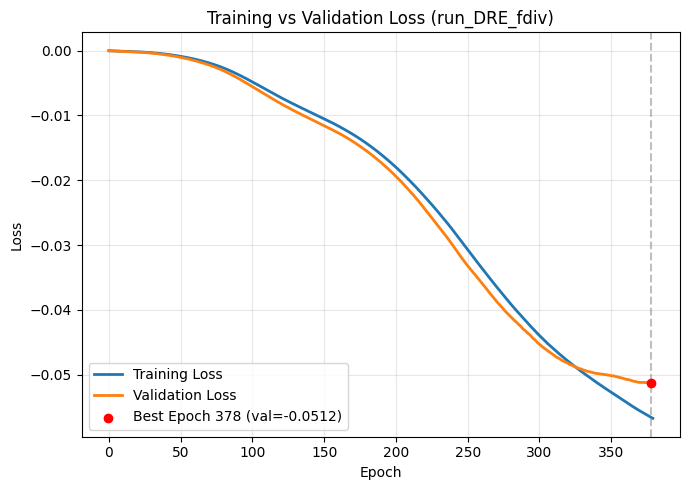

In [ ]:
# %%

# 2. (default) estimate the density ratio using f-div loss function and MLP
reload(dre)

num_epochs = 1000


x_p = torch.from_numpy(np.array(Y1_20, dtype = np.float32))
x_q = torch.from_numpy(np.array(Y2_20, dtype = np.float32))

x_p_val = torch.from_numpy(np.array(Y1_20_val, dtype = np.float32))
x_q_val = torch.from_numpy(np.array(Y2_20_val, dtype = np.float32))

stacked_Y_20 = np.vstack((Y1_20, Y2_20))
x_mixed = torch.from_numpy(np.array(stacked_Y_20, dtype = np.float32))

stacked_Y_20_val = np.vstack((Y1_20_val, Y2_20_val))
x_mixed_val = torch.from_numpy(np.array(stacked_Y_20_val, dtype = np.float32))

model1, losses1, val_loss = dre.run_DRE_fdiv(x_p,x_mixed,xi=0.5,
                                    x_p_val=x_p_val, x_q_val=x_mixed_val,
                                   num_epochs = num_epochs,
                                   early_patience = 5,
                                   loss_method='Hellinger')

plt.figure(figsize=(7,5))

# Plot training loss (every epoch)
plt.plot(np.arange(len(losses1)), losses1, label="Training Loss", color="tab:blue", linewidth=2)

# Plot validation loss (may have fewer points)
if val_loss and len(val_loss) > 0:
    plt.plot(np.arange(len(val_loss)), val_loss, label="Validation Loss", color="tab:orange", linewidth=2)
    # mark best epoch
    best_epoch = int(np.argmin(val_loss))
    best_val = float(val_loss[best_epoch])
    plt.axvline(best_epoch, color="gray", linestyle="--", alpha=0.5)
    plt.scatter(best_epoch, best_val, color="red", zorder=5, label=f"Best Epoch {best_epoch} (val={best_val:.4f})")
    print(f"Best epoch = {best_epoch} | val_loss = {best_val:.6f}")
else:
    print("No validation losses recorded.")

# Styling
plt.title("Training vs Validation Loss (run_DRE_fdiv)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

with torch.no_grad():
    w_vis1_train = model1(torch.from_numpy(stacked_Y_20).float())

w_vis1_train = w_vis1_train.detach().numpy()

reload(help)
ratio_20D = help.RDR_20D_theoretical(
    stacked_Y_20, K, weights, means1, covariances1, means2, covariances2, noise_sd
)

In [ ]:
# %% 

# uLSIF
from densratio import densratio

# Fit uLSIF (the default)
result_uLSIF = densratio(Y1_20, stacked_Y_20, alpha=0, sigma_range=[0.1, 0.3, 1.0]) 
# r(x) estimates the density ratio p(x)/q(x)
r_uLSIF = result_uLSIF.compute_density_ratio(stacked_Y_20)

RuLSIF starting...
Searching for the optimal sigma and lambda...
sigma = 0.10000, lambda = 0.00100, score = -0.00000
sigma = 0.10000, lambda = 0.01000, score = -0.00000
sigma = 0.10000, lambda = 0.10000, score = -0.00000
sigma = 0.10000, lambda = 1.00000, score = -0.00000
sigma = 0.10000, lambda = 10.00000, score = -0.00000
sigma = 0.10000, lambda = 100.00000, score = -0.00000
sigma = 0.10000, lambda = 1000.00000, score = -0.00000
sigma = 0.10000, lambda = 10000.00000, score = -0.00000
sigma = 0.10000, lambda = 100000.00000, score = -0.00000
sigma = 0.10000, lambda = 1000000.00000, score = -0.00000
sigma = 0.10000, lambda = 10000000.00000, score = -0.00000
sigma = 0.10000, lambda = 100000000.00000, score = -0.00000
sigma = 0.10000, lambda = 1000000000.00000, score = -0.00000
sigma = 0.30000, lambda = 0.00100, score = -0.00001
sigma = 0.30000, lambda = 0.01000, score = -0.00000
sigma = 0.30000, lambda = 0.10000, score = -0.00000
sigma = 0.30000, lambda = 1.00000, score = -0.00000
sigma 

In [ ]:
# %%

# KLIEP
import numpy as np
from adapt.instance_based import KLIEP

kliep = KLIEP(kernel="rbf", max_centers=100, cv=5, verbose=0)
kliep.fit(stacked_Y_20,np.zeros(len(stacked_Y_20)), Xt=Y1_20)              # fits the ratio estimator
r_KLIEP = kliep.predict_weights(stacked_Y_20)  # evaluate p/q on test data

In [ ]:
# %%

# Binary classification rule
# Xp ~ p, Xq ~ q
reload(help)
r_hat, eta, info = help.density_ratio_classifier(Y1_20, Y2_20, 
                            X_eval=stacked_Y_20, balance_priors=True)

# If you use RDR later:
r_bin = 2 * r_hat / (1 + r_hat)

Text(0, 0.5, 'x2')

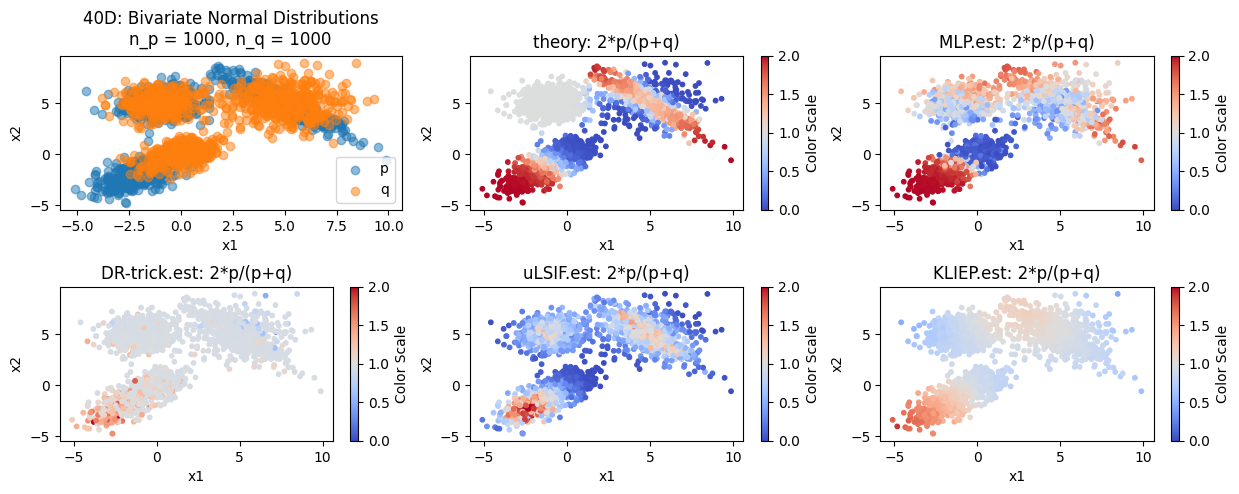

In [ ]:
# %% visualize

# Create two subplots side by side
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 5))
fig.subplots_adjust(hspace=0.50) 
color_range = [0,2]

# raw data
ax  = axs[0,0]
ax.scatter(Y1[:, 0], Y1[:, 1], alpha=0.5, label = 'p')
ax.scatter(Y2[:, 0], Y2[:, 1], alpha=0.5, label = 'q')
ax.set_title(
    f'{D}D: Bivariate Normal Distributions\nn_p = {n1_samples}, n_q = {n2_samples}',
    linespacing=1.2,  # spacing between the two lines
    pad=8             # distance from axes to title
)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend()

# Theory r
ax  = axs[0,1]
sc=ax.scatter(stacked_Y_train[:,0], stacked_Y_train[:,1], c=ratio_20D, # ratios_train for latent
                     cmap="coolwarm", marker='o', s=10,
                     norm = TwoSlopeNorm(vmin=color_range[0], 
                                         vcenter=1, 
                                         vmax=color_range[1]) ) # s is the marker size
ax.set_title('theory: 2*p/(p+q)')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Color Scale')
ax.set_xlabel('x1')
ax.set_ylabel('x2')

# MLP r
ax  = axs[0,2]
sc=ax.scatter(stacked_Y_train[:,0], stacked_Y_train[:,1], c=w_vis1_train, 
                     cmap="coolwarm", marker='o', s=10,
                     norm = TwoSlopeNorm(vmin=color_range[0], 
                                         vcenter=1, 
                                         vmax=color_range[1]) ) # s is the marker size
ax.set_title('MLP.est: 2*p/(p+q)')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Color Scale')
ax.set_xlabel('x1')
ax.set_ylabel('x2')

# bin r
ax  = axs[1,0]
sc=ax.scatter(stacked_Y_train[:,0], stacked_Y_train[:,1], c=r_bin, 
                     cmap="coolwarm", marker='o', s=10,
                     norm = TwoSlopeNorm(vmin=color_range[0], 
                                         vcenter=1, 
                                         vmax=color_range[1]) ) # s is the marker size
ax.set_title('DR-trick.est: 2*p/(p+q)')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Color Scale')
ax.set_xlabel('x1')
ax.set_ylabel('x2')

# uLSIF r
ax  = axs[1,1]
sc=ax.scatter(stacked_Y_train[:,0], stacked_Y_train[:,1], c=r_uLSIF, 
                     cmap="coolwarm", marker='o', s=10,
                     norm = TwoSlopeNorm(vmin=color_range[0], 
                                         vcenter=1, 
                                         vmax=color_range[1]) ) # s is the marker size
ax.set_title('uLSIF.est: 2*p/(p+q)')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Color Scale')
ax.set_xlabel('x1')
ax.set_ylabel('x2')

# KLIEP r
ax  = axs[1,2]
sc=ax.scatter(stacked_Y_train[:,0], stacked_Y_train[:,1], c=r_KLIEP, 
                     cmap="coolwarm", marker='o', s=10,
                     norm = TwoSlopeNorm(vmin=color_range[0], 
                                         vcenter=1, 
                                         vmax=color_range[1]) ) # s is the marker size
ax.set_title('KLIEP.est: 2*p/(p+q)')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Color Scale')
ax.set_xlabel('x1')
ax.set_ylabel('x2')

In [ ]:
# %%

# compare MSE
# true ratios (e.g., r_true = p(x)/q(x) or 2p/(p+q))
r_true = ratio_20D

# estimated ratios
r_mlp   = w_vis1_train   # from your neural network
r_ulsif = r_uLSIF        # from densratio/uLSIF
r_kliep = r_KLIEP        # from ADAPT.KLIEP (make sure orientation is p/q)

# ensure consistent shapes and finite values
def mse(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.mean((y_true[mask] - y_pred[mask])**2)

mse_mlp   = mse(r_true, r_mlp)
mse_ulsif = mse(r_true, r_ulsif)
mse_kliep = mse(r_true, r_kliep)
mse_bin = mse(r_true, r_bin)


print(f"MSE (MLP):   {mse_mlp:.4f}")
print(f"MSE (DR-trick):   {mse_bin:.4f}")
print(f"MSE (uLSIF): {mse_ulsif:.4f}")
print(f"MSE (KLIEP): {mse_kliep:.4f}")

MSE (MLP):   0.1561
MSE (DR-trick):   0.2989
MSE (uLSIF): 0.2242
MSE (KLIEP): 0.2322
